# Statistical Machine Learning

Notebook ini merangkum Chapter 6 dari *Practical Statistics for Data Scientists* edisi kedua. Chapter ini membahas statistical machine learning sebagai kelompok metode supervised learning yang lebih fleksibel dan data-driven dibanding model statistik klasik yang biasanya menetapkan struktur linear sejak awal.

Pembahasan dibuat ringkas mengikuti format Chapter 5 yang dijadikan patokan: terdapat tujuan pembelajaran, ringkasan chapter, penjelasan teori per bagian, rumus matematis yang relevan, contoh kode inti, hubungan antar konsep, dan kesimpulan chapter.

## Tujuan Pembelajaran

- Memahami perbedaan umum antara statistical machine learning dan pendekatan statistik klasik.
- Menjelaskan K-Nearest Neighbors (KNN) untuk classification dan regression.
- Memahami distance metrics, one-hot encoding, standardization, dan pemilihan nilai $K$ pada KNN.
- Menjelaskan decision tree sebagai model berbasis aturan dan recursive partitioning.
- Memahami impurity measures seperti Gini impurity dan entropy.
- Menjelaskan overfitting pada tree model dan cara mengontrol kompleksitas tree.
- Memahami bagging, random forest, out-of-bag error, dan variable importance.
- Menjelaskan boosting sebagai ensemble model yang membangun model secara bertahap.
- Memahami regularization dan hyperparameter tuning pada boosting, khususnya XGBoost.

## Ringkasan Chapter

Chapter ini membahas metode predictive modeling yang lebih fleksibel dan otomatis dibanding model statistik klasik. Metode dalam chapter ini tetap termasuk supervised learning karena dilatih pada data dengan outcome yang diketahui, kemudian digunakan untuk memprediksi outcome pada data baru.

Bagian pertama membahas K-Nearest Neighbors atau KNN. KNN memprediksi class atau nilai suatu record berdasarkan record training yang paling mirip. Kemiripan dihitung menggunakan distance metric, misalnya Euclidean distance atau Manhattan distance. Karena distance sangat dipengaruhi skala variabel, standardization menjadi langkah penting sebelum menerapkan KNN.

Selanjutnya, chapter membahas tree models atau decision trees. Tree model membagi data secara berulang menggunakan aturan if-then-else agar setiap partition menjadi semakin homogen terhadap outcome. Proses ini disebut recursive partitioning. Tree model mudah dikomunikasikan karena menghasilkan aturan keputusan, tetapi tree yang terlalu besar mudah overfit terhadap training data.

Bagian berikutnya membahas bagging dan random forest. Bagging membangun banyak model dari bootstrap samples, lalu menggabungkan hasilnya melalui average atau majority vote. Random forest memperluas bagging pada decision trees dengan menambahkan pemilihan random subset of variables pada setiap split. Pendekatan ini biasanya lebih akurat dibanding single tree, tetapi lebih sulit diinterpretasikan.

Bagian akhir membahas boosting. Boosting membangun model secara berurutan, dengan setiap model baru memberi perhatian lebih pada record yang masih memiliki error besar. XGBoost dibahas sebagai implementasi boosting yang populer dan efisien. Karena boosting sangat fleksibel, regularization dan cross-validation menjadi penting untuk menghindari overfitting.

## Statistical Machine Learning

Statistical machine learning dalam chapter ini mengacu pada metode yang belajar secara fleksibel dari data tanpa memaksakan struktur global seperti linear regression. Model seperti KNN, decision tree, random forest, dan boosting lebih fokus pada predictive performance.

Perbedaan umum:

| Pendekatan | Fokus Utama |
|---|---|
| Statistik klasik | Struktur probabilistik, interpretasi model, dan hubungan antar variabel. |
| Machine learning | Algoritma efisien, kemampuan prediksi, dan skalabilitas pada data besar. |

Dalam praktik, batas antara statistik dan machine learning tidak selalu jelas. Banyak metode modern dikembangkan dari tradisi statistik tetapi digunakan luas dalam machine learning.

## K-Nearest Neighbors

K-Nearest Neighbors atau KNN adalah metode yang memprediksi outcome sebuah record berdasarkan $K$ record training yang paling mirip. Untuk classification, prediksi biasanya ditentukan melalui majority vote. Untuk regression, prediksi ditentukan dari rata-rata nilai target para tetangga terdekat.

Langkah umum KNN:

1. Tentukan record baru yang akan diprediksi.
2. Hitung jarak record baru ke semua record training.
3. Pilih $K$ record dengan jarak paling dekat.
4. Untuk classification, gunakan majority class.
5. Untuk regression, gunakan rata-rata target value.

KNN sederhana dan intuitif, tetapi hasilnya sangat bergantung pada scaling variabel, distance metric, dan pilihan $K$.

## Distance Metrics

Distance metric mengukur seberapa jauh dua record dari satu sama lain. Dua distance metric yang dibahas chapter adalah Euclidean distance dan Manhattan distance.

### Euclidean Distance

$$
d(x,u)
=
\sqrt{
(x_1-u_1)^2+(x_2-u_2)^2+\cdots+(x_p-u_p)^2
}
$$

### Manhattan Distance

$$
d(x,u)
=
|x_1-u_1|+|x_2-u_2|+\cdots+|x_p-u_p|
$$

Keterangan:

- $x$ dan $u$ = dua record yang dibandingkan
- $p$ = jumlah predictor variables
- Euclidean distance = jarak garis lurus
- Manhattan distance = jarak yang bergerak per arah, seperti blok kota

Jika satu variabel memiliki skala jauh lebih besar, variabel tersebut dapat mendominasi distance calculation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

np.random.seed(2024)

# Simulasi data loan default dengan dua predictor utama
n = 900
borrower_score = np.random.beta(4, 3, n)
payment_inc_ratio = np.random.gamma(2.0, 3.0, n).clip(0, 25)
dti = np.random.normal(18, 6, n).clip(1, 40)
revol_bal = np.random.lognormal(9.2, 0.8, n)
revol_util = np.random.uniform(0, 100, n)

logit_default = 1.7 + 0.08 * payment_inc_ratio + 0.025 * dti - 4.2 * borrower_score
prob_default = 1 / (1 + np.exp(-logit_default))
outcome = np.where(np.random.rand(n) < prob_default, "default", "paid off")

loan = pd.DataFrame({
    "borrower_score": borrower_score,
    "payment_inc_ratio": payment_inc_ratio,
    "dti": dti,
    "revol_bal": revol_bal,
    "revol_util": revol_util,
    "outcome": outcome
})

loan.head()

,borrower_score,payment_inc_ratio,dti,revol_bal,revol_util,outcome
0,0.659849,9.350791,24.602670,5703.083572,56.455492,default
1,0.575709,5.384789,25.306111,4575.539272,75.269029,default
2,0.363062,7.246970,16.892592,8343.387185,15.953882,paid off
3,0.619562,19.484451,19.197818,8747.894602,88.477714,default
4,0.397788,2.087298,18.333812,7076.326059,23.477650,default


## Contoh KNN untuk Loan Default

Contoh berikut menggunakan dua predictor: `payment_inc_ratio` dan `dti`. Model KNN mencari record training yang paling dekat dengan record baru, kemudian menentukan outcome berdasarkan mayoritas tetangga terdekat.

Probability dari KNN dapat dihitung dari proporsi class tertentu di antara $K$ tetangga terdekat. Misalnya, jika 9 dari 20 tetangga adalah default, maka probability default adalah $9/20 = 0.45$.

In [2]:
predictors_knn = ["payment_inc_ratio", "dti"]
X = loan[predictors_knn]
y = loan["outcome"]

newloan = pd.DataFrame({
    "payment_inc_ratio": [9.0],
    "dti": [22.5]
})

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)

prediction = knn.predict(newloan)[0]
probability = pd.DataFrame(knn.predict_proba(newloan), columns=knn.classes_)

print("Predicted class:", prediction)
display(probability)

Predicted class: default


,default,paid off
0,0.5,0.5


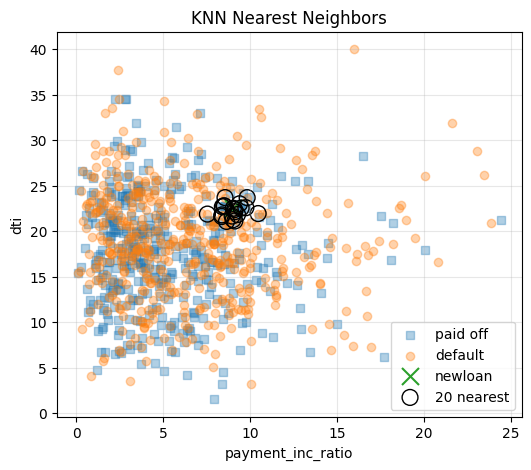

In [3]:
# Visualisasi tetangga terdekat
distances, indices = knn.kneighbors(newloan)
neighbors = loan.iloc[indices[0]]

plt.figure(figsize=(6, 5))

for label, marker in [("paid off", "s"), ("default", "o")]:
    subset = loan[loan["outcome"] == label]
    plt.scatter(
        subset["payment_inc_ratio"],
        subset["dti"],
        alpha=0.35,
        marker=marker,
        label=label
    )

plt.scatter(newloan["payment_inc_ratio"], newloan["dti"], marker="x", s=150, label="newloan")
plt.scatter(neighbors["payment_inc_ratio"], neighbors["dti"], s=130, facecolors="none", edgecolors="black", label="20 nearest")
plt.xlabel("payment_inc_ratio")
plt.ylabel("dti")
plt.title("KNN Nearest Neighbors")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## One Hot Encoding

Banyak machine learning algorithms membutuhkan input numeric. Oleh karena itu, factor atau categorical variables perlu diubah menjadi dummy variables. Proses ini disebut one-hot encoding.

Jika variabel `home ownership` memiliki empat kategori, one-hot encoding akan membuat empat binary columns. Pada linear atau logistic regression, salah satu dummy biasanya dihapus untuk menghindari multicollinearity. Pada KNN dan tree-based methods, hal ini biasanya bukan masalah utama.

In [4]:
loan_factor = pd.DataFrame({
    "home_ownership": ["MORTGAGE", "MORTGAGE", "RENT", "OWN", "OTHER", "RENT"],
    "purpose": ["debt_consolidation", "credit_card", "small_business", "moving", "credit_card", "debt_consolidation"]
})

encoded = pd.get_dummies(loan_factor, dtype=int)

display(loan_factor)
display(encoded)

,home_ownership,purpose
0,MORTGAGE,debt_consolidation
1,MORTGAGE,credit_card
2,RENT,small_business
3,OWN,moving
4,OTHER,credit_card
5,RENT,debt_consolidation


,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_credit_card,purpose_debt_consolidation,purpose_moving,purpose_small_business
0,1,0,0,0,0,1,0,0
1,1,0,0,0,1,0,0,0
2,0,0,0,1,0,0,0,1
3,0,0,1,0,0,0,1,0
4,0,1,0,0,1,0,0,0
5,0,0,0,1,0,1,0,0


## Standardization

Standardization atau normalization dalam konteks statistik mengubah nilai ke dalam z-score. Tujuannya adalah membuat variabel berada pada skala yang sebanding, sehingga variabel berskala besar tidak mendominasi distance metric.

### Rumus Z-Score

$$
z =
\frac{x-\bar{x}}{s}
$$

Keterangan:

- $x$ = nilai asli
- $\bar{x}$ = mean
- $s$ = standard deviation
- $z$ = nilai setelah standardization

Standardization tidak mengubah bentuk distribusi data menjadi normal. Standardization hanya mengubah pusat dan skala data.

In [5]:
predictors_scale = ["payment_inc_ratio", "dti", "revol_bal", "revol_util"]

newloan_full = loan.loc[[0], predictors_scale]
X_full = loan.loc[1:, predictors_scale]
y_full = loan.loc[1:, "outcome"]

knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_full, y_full)
raw_neighbors_idx = knn_raw.kneighbors(newloan_full)[1][0]

scaler = StandardScaler()
X_std = scaler.fit_transform(X_full)
newloan_std = scaler.transform(newloan_full)

knn_std = KNeighborsClassifier(n_neighbors=5)
knn_std.fit(X_std, y_full)
std_neighbors_idx = knn_std.kneighbors(newloan_std)[1][0]

print("Nearest neighbors without standardization:")
display(X_full.iloc[raw_neighbors_idx])

print("Nearest neighbors with standardization:")
display(X_full.iloc[std_neighbors_idx])

Nearest neighbors without standardization:


,payment_inc_ratio,dti,revol_bal,revol_util
115,18.135420,16.879799,5718.538696,25.301224
263,3.672171,16.649313,5700.792734,19.430673
787,3.168922,21.612092,5745.566911,47.985054
492,3.455293,23.873490,5668.206869,24.922261
58,5.094429,20.628975,5681.606611,10.665937


Nearest neighbors with standardization:


,payment_inc_ratio,dti,revol_bal,revol_util
643,9.495603,22.534709,5450.676291,62.057027
281,8.828771,24.833565,5365.825634,67.308431
276,8.978307,21.653418,6552.301601,61.525234
118,8.381294,21.609550,5867.688717,56.589586
675,9.406982,23.001792,7274.401881,70.327008


## Choosing K

Nilai $K$ sangat memengaruhi performa KNN. Jika $K$ terlalu kecil, model dapat overfit karena terlalu sensitif terhadap noise lokal. Jika $K$ terlalu besar, model dapat oversmooth dan kehilangan struktur lokal yang penting.

Secara umum:

| Nilai K | Dampak |
|---|---|
| Terlalu kecil | Variance tinggi, mudah overfit. |
| Terlalu besar | Bias tinggi, terlalu smooth. |
| Dipilih dengan validasi | Lebih seimbang untuk data baru. |

Tidak ada aturan universal untuk memilih $K$. Nilai terbaik biasanya dipilih melalui holdout validation atau cross-validation.

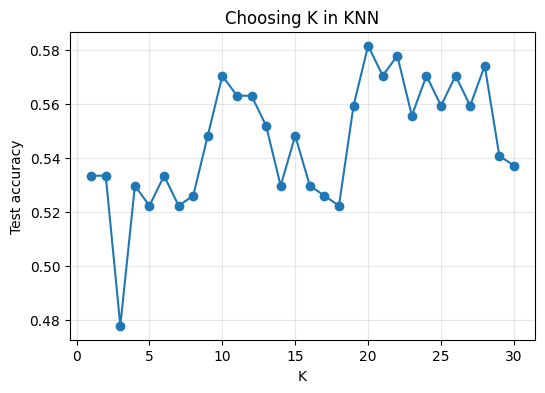

Best K: 20
Best test accuracy: 0.581


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    loan[predictors_scale], loan["outcome"], test_size=0.30, random_state=2024, stratify=loan["outcome"]
)

k_values = range(1, 31)
accuracies = []

for k in k_values:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    accuracies.append(accuracy_score(y_test, pred))

plt.figure(figsize=(6, 4))
plt.plot(list(k_values), accuracies, marker="o")
plt.xlabel("K")
plt.ylabel("Test accuracy")
plt.title("Choosing K in KNN")
plt.grid(alpha=0.3)
plt.show()

best_k = list(k_values)[int(np.argmax(accuracies))]
print("Best K:", best_k)
print("Best test accuracy:", round(max(accuracies), 3))

## KNN as a Feature Engine

KNN tidak selalu digunakan sebagai model akhir. Chapter menjelaskan bahwa KNN dapat digunakan sebagai feature engine, yaitu menghasilkan feature baru berupa probability atau quasi-probability dari class tertentu.

Prosesnya:

1. Jalankan KNN pada data.
2. Ambil predicted probability dari class tertentu.
3. Tambahkan probability tersebut sebagai feature baru.
4. Gunakan feature baru pada model tahap kedua.

Ide ini memberi model tahap kedua tambahan informasi lokal dari data.

In [7]:
feature_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=20))
])

feature_knn.fit(loan[predictors_scale], loan["outcome"])
borrower_score_knn = feature_knn.predict_proba(loan[predictors_scale])[:, list(feature_knn.named_steps["knn"].classes_).index("default")]

loan["borrower_score_knn"] = borrower_score_knn

loan[["borrower_score", "payment_inc_ratio", "dti", "borrower_score_knn"]].head()

,borrower_score,payment_inc_ratio,dti,borrower_score_knn
0,0.659849,9.350791,24.602670,0.80
1,0.575709,5.384789,25.306111,0.75
2,0.363062,7.246970,16.892592,0.55
3,0.619562,19.484451,19.197818,0.80
4,0.397788,2.087298,18.333812,0.40


## Tree Models

Tree models atau decision trees menghasilkan aturan if-then-else untuk memprediksi class atau nilai continuous. Tree membagi data secara berulang ke dalam subpartitions agar outcome dalam setiap partition menjadi semakin homogen.

Istilah penting:

| Istilah | Penjelasan |
|---|---|
| Recursive partitioning | Proses membagi data secara berulang. |
| Split value | Nilai predictor yang digunakan untuk memisahkan records. |
| Node | Titik aturan split pada tree. |
| Leaf | Node akhir yang menghasilkan prediksi. |
| Impurity | Tingkat campuran class dalam partition. |
| Pruning | Mengurangi cabang tree agar tidak overfit. |

Keunggulan single tree adalah mudah dipahami dan dikomunikasikan, tetapi performanya biasanya kalah dari ensemble trees.

## Recursive Partitioning

Recursive partitioning mencari split terbaik pada predictor variable agar subpartition menjadi lebih homogen.

Prosedur umum:

1. Untuk setiap predictor, coba beberapa split values.
2. Untuk setiap split, ukur impurity pada subpartitions yang terbentuk.
3. Pilih split dengan impurity terendah.
4. Ulangi proses pada subpartitions.
5. Berhenti jika tidak ada split yang cukup meningkatkan homogeneity.

Prediksi probability pada leaf dapat dihitung sebagai proporsi class 1 dalam leaf:

$$
P(Y=1)
=
\frac{\text{Number of 1s in the partition}}{\text{Size of the partition}}
$$

Decision tree accuracy: 0.658


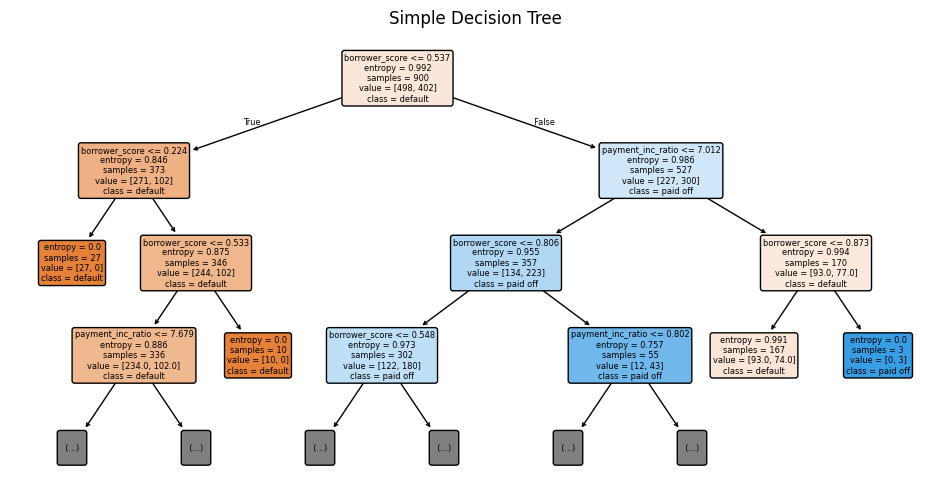

In [8]:
tree_predictors = ["borrower_score", "payment_inc_ratio"]
X_tree = loan[tree_predictors]
y_tree = loan["outcome"]

tree = DecisionTreeClassifier(
    random_state=2024,
    criterion="entropy",
    min_impurity_decrease=0.003,
    max_depth=4
)

tree.fit(X_tree, y_tree)
pred_tree = tree.predict(X_tree)

print("Decision tree accuracy:", round(accuracy_score(y_tree, pred_tree), 3))

plt.figure(figsize=(12, 6))
plot_tree(
    tree,
    feature_names=tree_predictors,
    class_names=tree.classes_,
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title("Simple Decision Tree")
plt.show()

## Measuring Homogeneity or Impurity

Tree models membutuhkan ukuran untuk menentukan apakah suatu partition sudah cukup homogen. Dua ukuran impurity yang umum adalah Gini impurity dan entropy.

### Gini Impurity

$$
I(A)=p(1-p)
$$

### Entropy

$$
I(A)=
-p\log_2(p)-(1-p)\log_2(1-p)
$$

Keterangan:

- $I(A)$ = impurity dari partition $A$
- $p$ = proporsi salah satu class dalam partition
- impurity rendah berarti partition lebih homogen
- impurity tinggi berarti class lebih bercampur

Accuracy bukan ukuran impurity yang ideal untuk memilih split karena kurang sensitif terhadap perubahan komposisi class.

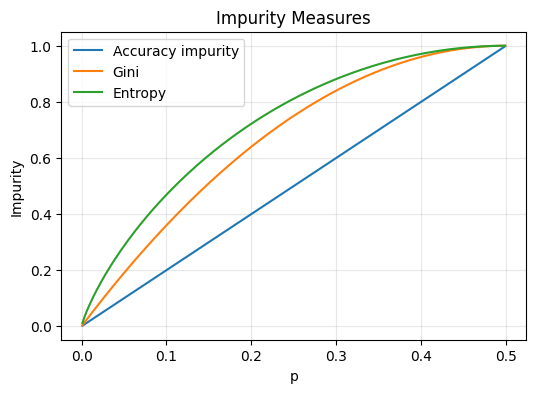

In [9]:
p = np.linspace(0.001, 0.499, 200)
accuracy_impurity = p / 0.5
gini = (p * (1 - p)) / 0.25
entropy = (-p*np.log2(p) - (1-p)*np.log2(1-p))

plt.figure(figsize=(6, 4))
plt.plot(p, accuracy_impurity, label="Accuracy impurity")
plt.plot(p, gini, label="Gini")
plt.plot(p, entropy, label="Entropy")
plt.xlabel("p")
plt.ylabel("Impurity")
plt.title("Impurity Measures")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Stopping Tree Growth

Tree yang terus dibiarkan tumbuh dapat mencapai purity sempurna pada training data. Namun, hal ini biasanya berarti model overfit terhadap noise. Karena itu, kompleksitas tree perlu dikontrol.

Beberapa parameter yang digunakan:

| Parameter | Fungsi |
|---|---|
| `max_depth` | Membatasi kedalaman tree. |
| `min_samples_split` | Minimum records untuk membagi node. |
| `min_samples_leaf` | Minimum records pada leaf. |
| `min_impurity_decrease` | Split hanya dilakukan jika impurity turun cukup besar. |

Nilai terbaik biasanya dipilih melalui cross-validation atau grid search.

In [10]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_leaf": [5, 10, 20, 40],
    "min_impurity_decrease": [0.0, 0.001, 0.003]
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=2024),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_tree.fit(X_tree, y_tree)

print("Best parameters:")
print(grid_tree.best_params_)
print("Best CV accuracy:", round(grid_tree.best_score_, 3))

Best parameters:
{'max_depth': 2, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5}
Best CV accuracy: 0.639


## Decision Tree Regression

Tree juga dapat digunakan untuk memprediksi nilai continuous. Untuk regression tree, impurity biasanya diukur menggunakan squared error dalam setiap partition. Prediksi pada leaf adalah rata-rata outcome records dalam leaf.

Metrik evaluasi yang umum digunakan adalah RMSE.

In [11]:
X_reg, y_reg = make_regression(
    n_samples=500,
    n_features=4,
    noise=30,
    random_state=2024
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=2024
)

tree_reg = DecisionTreeRegressor(max_depth=4, random_state=2024)
tree_reg.fit(X_train_reg, y_train_reg)

pred_reg = tree_reg.predict(X_test_reg)
rmse_reg = np.sqrt(mean_squared_error(y_test_reg, pred_reg))

print("Decision tree regression RMSE:", round(rmse_reg, 2))

Decision tree regression RMSE: 48.64


## Bagging

Bagging adalah singkatan dari bootstrap aggregating. Ide dasarnya adalah membangun banyak model dari bootstrap samples, lalu menggabungkan prediksinya.

Langkah bagging:

1. Ambil bootstrap sample dari training data.
2. Latih model pada bootstrap sample tersebut.
3. Ulangi proses berkali-kali.
4. Gabungkan prediksi model melalui average atau majority vote.

Untuk classification probability, bagged estimate dapat ditulis sebagai:

$$
\hat{f}
=
\frac{1}{M}
\left(
\hat{f}_1(X)+\hat{f}_2(X)+\cdots+\hat{f}_M(X)
\right)
$$

Keterangan:

- $M$ = jumlah model
- $\hat{f}_m(X)$ = prediksi dari model ke-$m$
- bagging mengurangi variance model

## Random Forest

Random forest menerapkan bagging pada decision trees, tetapi dengan satu tambahan penting: pada setiap split, model hanya mempertimbangkan subset predictor variables yang dipilih secara acak.

Perbedaan penting:

| Model | Ciri |
|---|---|
| Single tree | Satu tree, mudah diinterpretasikan, tetapi rawan overfit. |
| Bagged trees | Banyak tree dari bootstrap samples. |
| Random forest | Bagged trees + random subset of variables pada setiap split. |

Random forest biasanya lebih akurat daripada single tree, tetapi interpretasi rule-based dari single tree hilang.

In [12]:
X_rf = loan[["borrower_score", "payment_inc_ratio", "dti", "revol_util", "borrower_score_knn"]]
y_rf = loan["outcome"]

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.30, random_state=2024, stratify=y_rf
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=2024,
    oob_score=True
)

rf.fit(X_train_rf, y_train_rf)

pred_rf = rf.predict(X_test_rf)
print("Random forest test accuracy:", round(accuracy_score(y_test_rf, pred_rf), 3))
print("Out-of-bag score:", round(rf.oob_score_, 3))

Random forest test accuracy: 0.663
Out-of-bag score: 0.632


## Out-of-Bag Error

Dalam random forest, setiap tree dilatih pada bootstrap sample. Records yang tidak masuk bootstrap sample untuk suatu tree disebut out-of-bag records. Records ini dapat digunakan untuk memperkirakan error tanpa validation set terpisah.

OOB score berguna karena memberi estimasi performa model dari data yang tidak digunakan oleh tree tertentu saat training.

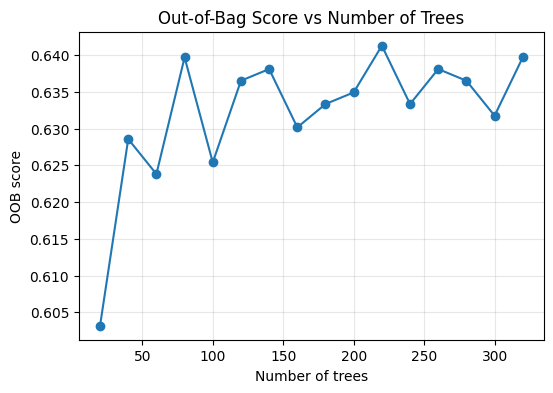

In [13]:
n_estimators_list = list(range(20, 321, 20))
oob_scores = []

for n_trees in n_estimators_list:
    rf_temp = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=5,
        random_state=2024,
        oob_score=True
    )
    rf_temp.fit(X_train_rf, y_train_rf)
    oob_scores.append(rf_temp.oob_score_)

plt.figure(figsize=(6, 4))
plt.plot(n_estimators_list, oob_scores, marker="o")
plt.xlabel("Number of trees")
plt.ylabel("OOB score")
plt.title("Out-of-Bag Score vs Number of Trees")
plt.grid(alpha=0.3)
plt.show()

## Variable Importance

Random forest dapat digunakan untuk mengukur variable importance. Chapter membahas dua pendekatan:

| Pendekatan | Penjelasan |
|---|---|
| Accuracy decrease | Nilai suatu variable diacak; jika akurasi turun besar, variable dianggap penting. |
| Gini decrease | Mengukur kontribusi variable dalam menurunkan Gini impurity pada nodes. |

Permutation importance lebih langsung mengukur dampak pada performa prediksi, sedangkan Gini importance berasal dari proses training tree.

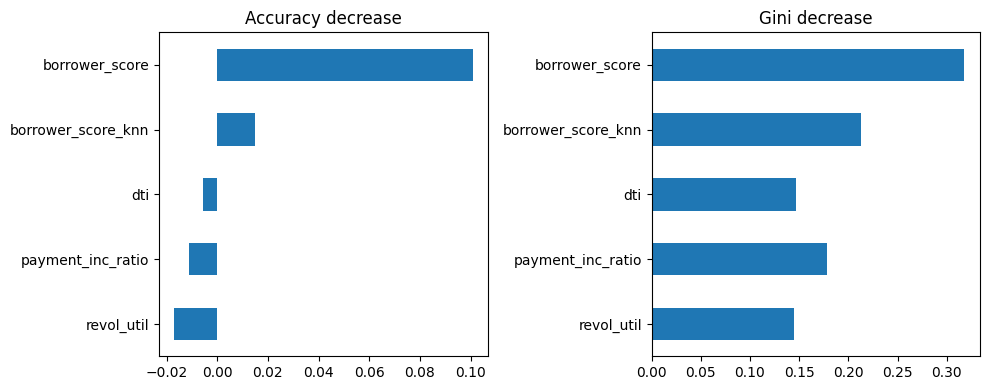

,feature,Permutation importance,Gini importance
3,revol_util,-0.017037,0.144392
1,payment_inc_ratio,-0.011111,0.178261
2,dti,-0.005556,0.146374
4,borrower_score_knn,0.014815,0.213044
0,borrower_score,0.100741,0.317930


In [14]:
perm_importance = permutation_importance(
    rf, X_test_rf, y_test_rf, n_repeats=10, random_state=2024
)

importance_df = pd.DataFrame({
    "feature": X_rf.columns,
    "Permutation importance": perm_importance.importances_mean,
    "Gini importance": rf.feature_importances_
}).sort_values("Permutation importance")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

importance_df.plot(
    kind="barh",
    x="feature",
    y="Permutation importance",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Accuracy decrease")
axes[0].set_ylabel("")

importance_df.plot(
    kind="barh",
    x="feature",
    y="Gini importance",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Gini decrease")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

importance_df

## Boosting

Boosting adalah ensemble method yang membangun model secara berurutan. Berbeda dari bagging yang membuat banyak model relatif independen, boosting membuat model baru dengan memberi perhatian lebih pada records yang masih sulit diprediksi oleh model sebelumnya.

Inti boosting:

1. Fit model awal.
2. Identifikasi error atau residual.
3. Fit model berikutnya untuk memperbaiki error tersebut.
4. Ulangi proses sampai sejumlah rounds.
5. Gabungkan model menjadi prediksi akhir.

Boosting sangat kuat, tetapi rawan overfitting jika hyperparameters tidak dikontrol.

## Regularization: Avoiding Overfitting

Boosting dapat overfit jika model terlalu kompleks atau terlalu agresif belajar dari error. Regularization membantu membatasi kompleksitas model.

Dalam XGBoost, objective function secara umum terdiri dari dua bagian:

$$
Obj = Loss + \Omega
$$

Keterangan:

- $Loss$ = error prediksi model
- $\Omega$ = penalty untuk kompleksitas model
- tujuan regularization = menjaga model tetap generalizable

Jika penalty terlalu kecil, model dapat overfit. Jika penalty terlalu besar, model dapat underfit.

In [15]:
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=2024
)

gb.fit(X_train_rf, y_train_rf)
pred_gb = gb.predict(X_test_rf)

print("Gradient boosting test accuracy:", round(accuracy_score(y_test_rf, pred_gb), 3))

# Optional XGBoost jika library tersedia
if XGBOOST_AVAILABLE:
    y_train_binary = (y_train_rf == "default").astype(int)
    y_test_binary = (y_test_rf == "default").astype(int)

    xgb = XGBClassifier(
        objective="binary:logistic",
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.7,
        colsample_bytree=0.8,
        random_state=2024,
        eval_metric="logloss"
    )
    xgb.fit(X_train_rf, y_train_binary)
    pred_xgb = xgb.predict(X_test_rf)
    print("XGBoost test accuracy:", round(accuracy_score(y_test_binary, pred_xgb), 3))
else:
    print("XGBoost tidak tersedia; contoh boosting dijalankan dengan GradientBoostingClassifier.")

Gradient boosting test accuracy: 0.659
XGBoost tidak tersedia; contoh boosting dijalankan dengan GradientBoostingClassifier.


## XGBoost Hyperparameters

Chapter menekankan bahwa hyperparameters XGBoost digunakan untuk menyeimbangkan predictive accuracy, overfitting, dan computational complexity.

| Hyperparameter | Penjelasan |
|---|---|
| `learning_rate` / `eta` | Shrinkage factor; nilai kecil membuat model belajar lebih lambat. |
| `n_estimators` / `nrounds` | Jumlah boosting rounds. |
| `max_depth` | Kedalaman maksimum tree; boosting biasanya memakai tree dangkal. |
| `subsample` | Proporsi records yang digunakan pada setiap round. |
| `colsample_bytree` | Proporsi predictors yang digunakan dalam tree. |
| `reg_lambda` dan `reg_alpha` | Regularization untuk mengontrol overfitting. |

Cross-validation penting karena boosting memiliki banyak hyperparameters yang saling memengaruhi.

In [16]:
param_grid_gb = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=2024),
    param_grid=param_grid_gb,
    cv=3,
    scoring="accuracy"
)

grid_gb.fit(X_train_rf, y_train_rf)

print("Best boosting parameters:")
print(grid_gb.best_params_)
print("Best CV accuracy:", round(grid_gb.best_score_, 3))

best_gb = grid_gb.best_estimator_
print("Test accuracy:", round(accuracy_score(y_test_rf, best_gb.predict(X_test_rf)), 3))

Best boosting parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}
Best CV accuracy: 0.613
Test accuracy: 0.685


## Perbandingan Model

Bagian berikut membandingkan beberapa metode yang dibahas dalam chapter. Tujuannya bukan mencari model terbaik universal, tetapi menunjukkan bahwa setiap metode memiliki karakteristik berbeda.

- KNN sederhana dan berbasis local similarity.
- Single decision tree mudah dijelaskan, tetapi rawan overfit.
- Random forest biasanya lebih stabil dan akurat.
- Boosting sering kuat, tetapi membutuhkan tuning lebih hati-hati.

In [17]:
models = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=best_k))
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=2024),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=5, random_state=2024),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=2024)
}

comparison_rows = []

for name, model in models.items():
    model.fit(X_train_rf, y_train_rf)
    pred = model.predict(X_test_rf)
    comparison_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test_rf, pred)
    })

pd.DataFrame(comparison_rows).sort_values("accuracy", ascending=False)

,model,accuracy
1,Decision Tree,0.666667
2,Random Forest,0.662963
3,Gradient Boosting,0.655556
0,KNN,0.637037


## Hubungan Antar Konsep

| Konsep | Deskripsi |
|---|---|
| Statistical machine learning | Metode supervised learning yang fleksibel dan data-driven. |
| KNN | Prediksi berdasarkan record yang paling mirip. |
| Distance metric | Ukuran jarak antar record. |
| Standardization | Mengubah variabel ke skala sebanding agar distance adil. |
| Bias-variance trade-off | Ketegangan antara model terlalu sederhana dan terlalu sensitif terhadap noise. |
| Decision tree | Model aturan if-then-else berbasis recursive partitioning. |
| Impurity | Ukuran heterogeneity dalam partition. |
| Pruning / complexity control | Cara mengurangi overfitting pada tree. |
| Bagging | Ensemble berbasis bootstrap samples. |
| Random forest | Bagging decision trees dengan random subset variables pada split. |
| OOB error | Estimasi error dari records yang tidak digunakan oleh tree tertentu. |
| Variable importance | Ukuran kontribusi predictor pada performa model. |
| Boosting | Ensemble berurutan yang memperbaiki error model sebelumnya. |
| Regularization | Penalti untuk mengontrol kompleksitas dan overfitting. |

## Kesimpulan Chapter

Chapter ini menjelaskan statistical machine learning sebagai kumpulan metode supervised learning yang fleksibel dan lebih berorientasi prediksi dibanding model statistik klasik. Metode yang dibahas tidak memaksakan struktur linear global, tetapi belajar dari pola lokal dan struktur data.

KNN memprediksi outcome berdasarkan record training yang paling mirip. Metode ini sederhana dan intuitif, tetapi sangat bergantung pada distance metric, scaling variabel, dan pemilihan nilai $K$. Standardization menjadi penting agar variabel berskala besar tidak mendominasi perhitungan jarak.

Decision tree membangun aturan if-then-else melalui recursive partitioning. Tree mudah dipahami dan dapat menangkap interaksi serta nonlinear relationships, tetapi tree yang terlalu besar dapat overfit. Oleh karena itu, kompleksitas tree perlu dikontrol melalui parameter seperti depth, minimum samples, impurity decrease, atau pruning.

Bagging dan random forest meningkatkan performa tree dengan membangun banyak tree dari bootstrap samples. Random forest menambahkan random subset of variables pada setiap split sehingga model lebih stabil dan biasanya lebih akurat daripada single tree. Namun, interpretasi rule-based menjadi lebih sulit.

Boosting membangun model secara berurutan untuk memperbaiki error model sebelumnya. XGBoost menjadi implementasi boosting yang populer karena efisien dan kuat. Akan tetapi, boosting mudah overfit jika hyperparameters tidak dituning. Regularization dan cross-validation menjadi bagian penting agar model tetap mampu generalize pada data baru.